Bibliotekos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### Pagrindinių komponentų analizė:

In [2]:
def PCA_Algorithm1 (data_scaled):
    pca = PCA(0.95)
    data_pca = pca.fit_transform(data_scaled)
    return (data_pca, pca.explained_variance_ratio_)

In [3]:
def PCA_Algorithm2 (data_scaled, n_comp):
    pca = PCA(n_components = n_comp)
    data_pca = pca.fit_transform(data_scaled)
    return (data_pca, pca.explained_variance_ratio_)

In [4]:
def PCA_Algorithm3 (data_scaled):
    pca = PCA(whiten = True)
    data_pca = pca.fit_transform(data_scaled)
    return (data_pca, pca.explained_variance_ratio_)

#### Pirmas duomenų rinkinys:

In [5]:
df_ellipsoid = pd.read_csv("ellipsoid.50d10c.8.txt", sep = '\t', header = None)
df_ellipsoid.head(5)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.006412,0.002997,-0.028828,-0.005403,0.070193,0.055493,-0.067224,-0.042464,0.040229,-0.027893,...,0.031264,0.051459,0.033878,0.050101,0.035105,-0.123535,-0.019261,0.052944,-0.070087,0.006853
1,0.101276,0.049836,0.058219,0.057525,0.052512,0.091341,-0.137052,0.034034,0.047139,-0.122298,...,0.027550,0.050529,0.110795,0.020408,-0.035099,-0.212835,0.001148,0.194039,-0.012406,0.027588
2,-0.025276,-0.024517,-0.058769,-0.007441,0.055704,0.048386,-0.026769,-0.059224,0.019099,0.020766,...,-0.018689,0.064856,0.028137,0.042149,0.060543,-0.085773,-0.024084,0.039798,-0.042798,-0.010927
3,0.087410,0.049991,0.050905,0.043360,0.051087,0.056953,-0.138113,0.020437,0.050432,-0.119749,...,0.029750,0.052365,0.092220,0.003401,0.003823,-0.201655,-0.026034,0.197960,-0.033710,0.001458
4,0.160108,0.064853,0.103496,0.080948,0.057654,0.114975,-0.193117,0.074163,0.066625,-0.203372,...,0.046991,0.037344,0.170901,0.009572,-0.071378,-0.276137,0.001418,0.267204,-0.022505,0.046585


In [6]:
print("Duomenų struktūra: ", df_ellipsoid.shape)

Duomenų struktūra:  (3140, 50)


In [7]:
sc = StandardScaler()
ellipsoid_scaled = sc.fit_transform(df_ellipsoid)
transformed_ellipsoid1, variance_ellipsoid1 = PCA_Algorithm1(ellipsoid_scaled)
variance_ellipsoid1_proc = np.round(variance_ellipsoid1 * 100, decimals = 1)

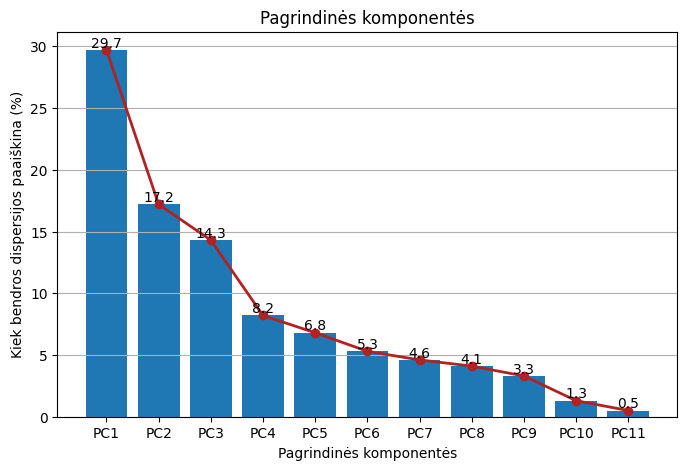

In [8]:
# var_pca_ellipsoid_10 = var_pca_ellipsoid1[:10]
labels = ["PC" + str(x) for x in range(1, len(variance_ellipsoid1_proc) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_ellipsoid1_proc) + 1), height = variance_ellipsoid1_proc, tick_label = labels)
plt.plot(range(1, len(variance_ellipsoid1_proc) + 1), variance_ellipsoid1_proc, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.bar_label(bars)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [9]:
transformed_ellipsoid3, variance_ellipsoid3 = PCA_Algorithm3(ellipsoid_scaled)
variance_ellipsoid3_proc = np.round(variance_ellipsoid3 * 100, decimals = 1)

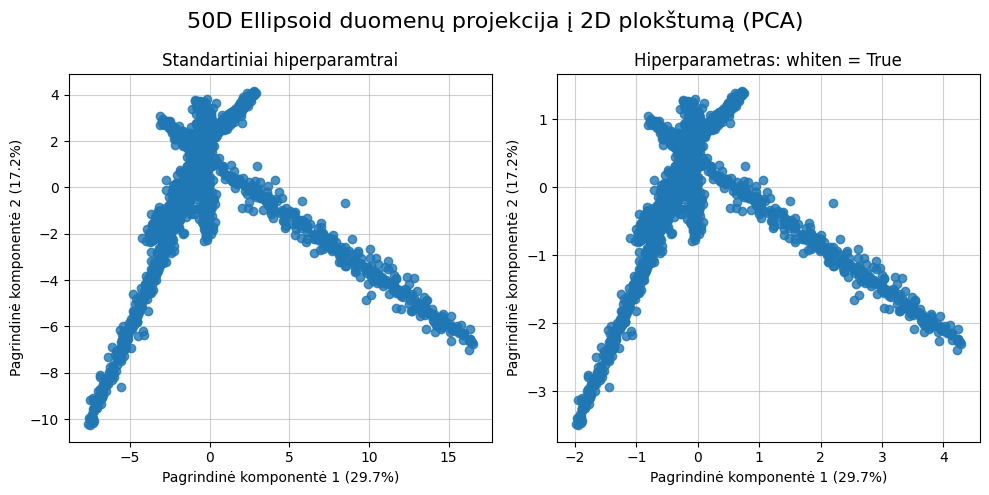

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_ellipsoid1[:, 0], transformed_ellipsoid1[:, 1], alpha=0.8)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_ellipsoid1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_ellipsoid1_proc[1]}%)")
ax1.grid(alpha=0.6)
ax1.set_axisbelow(True)

ax2.scatter(transformed_ellipsoid3[:, 0], transformed_ellipsoid3[:, 1], alpha=0.8)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_ellipsoid3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_ellipsoid3_proc[1]}%)")
ax2.grid(alpha=0.6)
ax2.set_axisbelow(True)

plt.suptitle("50D Ellipsoid duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

Hiperparametras *svd_solver*:

In [11]:
def pca_solvers(data):
    solvers = ['auto', 'full', 'covariance_eigh', 'arpack', 'randomized']
    results = {}

    for s in solvers:
        start_time = time.time()
        pca = PCA(svd_solver = s)
        pca.fit(data)
        end_time = time.time()
        results[s] = end_time - start_time

    print("Vykdymo laikai: ", results)

In [12]:
pca_solvers(ellipsoid_scaled)

Vykdymo laikai:  {'auto': 0.001997232437133789, 'full': 0.024494171142578125, 'covariance_eigh': 0.0019981861114501953, 'arpack': 0.06913232803344727, 'randomized': 0.08627033233642578}


-----

#### Antras duomenų rinkinys:

In [13]:
df_iris = pd.read_csv("iris.txt", sep = '\t', header = None)
df_iris.head(5)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
print("Duomenų struktūra: ", df_iris.shape)

Duomenų struktūra:  (150, 4)


In [15]:
iris_scaled = sc.fit_transform(df_iris)
transformed_iris2, variance_iris2 = PCA_Algorithm2(iris_scaled, 4)
variance_iris2_proc = np.round(variance_iris2 * 100, decimals = 1)

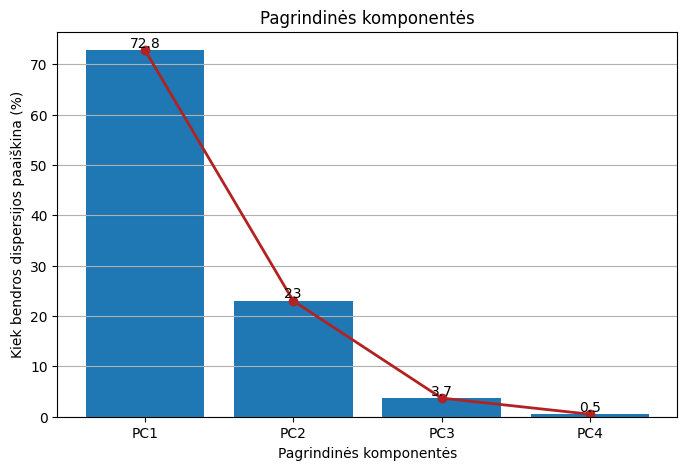

In [16]:
labels = ["PC" + str(x) for x in range(1, len(variance_iris2_proc) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_iris2_proc) + 1), height = variance_iris2_proc, tick_label = labels)
plt.bar_label(bars)
plt.plot(range(1, len(variance_iris2_proc) + 1), variance_iris2_proc, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [17]:
transformed_iris3, variance_iris3 = PCA_Algorithm3(iris_scaled)
variance_iris3_proc = np.round(variance_iris3 * 100, decimals = 1)

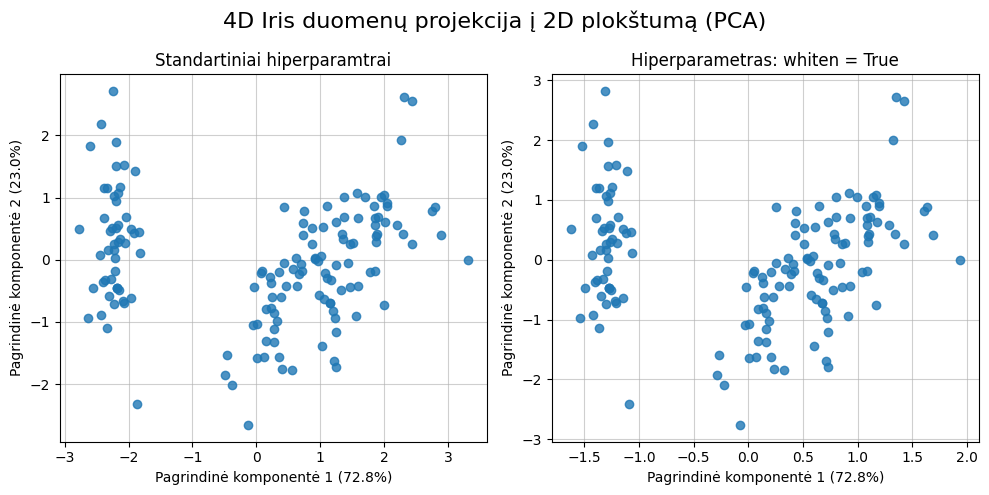

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_iris2[:, 0], transformed_iris2[:, 1], alpha=0.8)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_iris2_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_iris2_proc[1]}%)")
ax1.grid(alpha=0.6)
ax1.set_axisbelow(True)

ax2.scatter(transformed_iris3[:, 0], transformed_iris3[:, 1], alpha=0.8)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_iris3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_iris3_proc[1]}%)")
ax2.grid(alpha=0.6)
ax2.set_axisbelow(True)

plt.suptitle("4D Iris duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
pca_solvers(iris_scaled)

Vykdymo laikai:  {'auto': 0.0009961128234863281, 'full': 0.001007080078125, 'covariance_eigh': 0.0, 'arpack': 0.002535581588745117, 'randomized': 0.001995563507080078}


-----

#### Trečias duomenų rinkinys:

In [20]:
df_train = pd.read_csv("mnist_train.csv", sep = ',')
df_train.head(5)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
y_labels = df_train['label']
df_train = df_train.drop('label', axis=1)

In [22]:
print("Skirtingų grupių skaičius:", len(y_labels.unique()))
print("Duomenų struktūra: ", df_train.shape)

Skirtingų grupių skaičius: 10
Duomenų struktūra:  (60000, 784)


In [23]:
train_scaled = sc.fit_transform(df_train)
transformed_train1, variance_train1 = PCA_Algorithm1(train_scaled)
variance_train1_proc = np.round(variance_train1 * 100, decimals = 1)

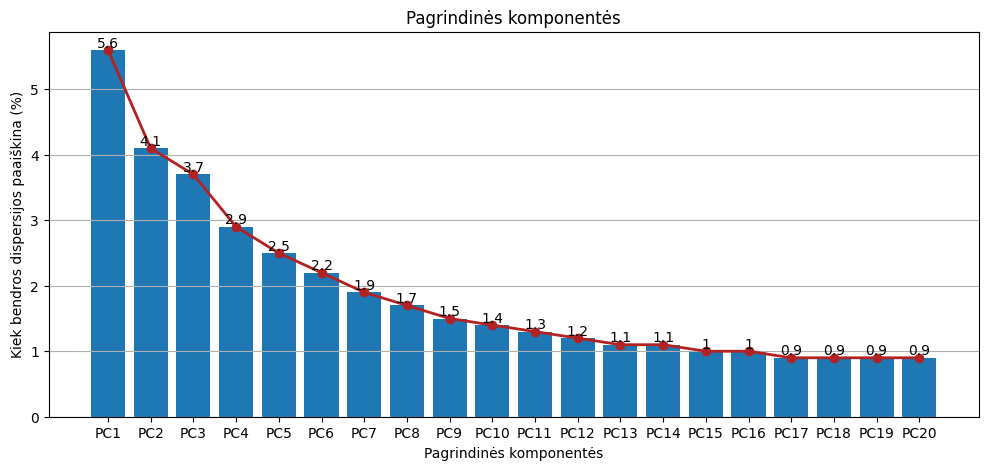

In [24]:
variance_train1_proc_top = variance_train1_proc[:20]
labels = ["PC" + str(x) for x in range(1, len(variance_train1_proc_top) + 1)]

plt.figure(figsize = (12, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_train1_proc_top) + 1), height = variance_train1_proc_top, tick_label = labels)
plt.bar_label(bars)
plt.plot(range(1, len(variance_train1_proc_top) + 1), variance_train1_proc_top, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [25]:
transformed_train3, variance_train3 = PCA_Algorithm3(train_scaled)
variance_train3_proc = np.round(variance_train3 * 100, decimals = 1)

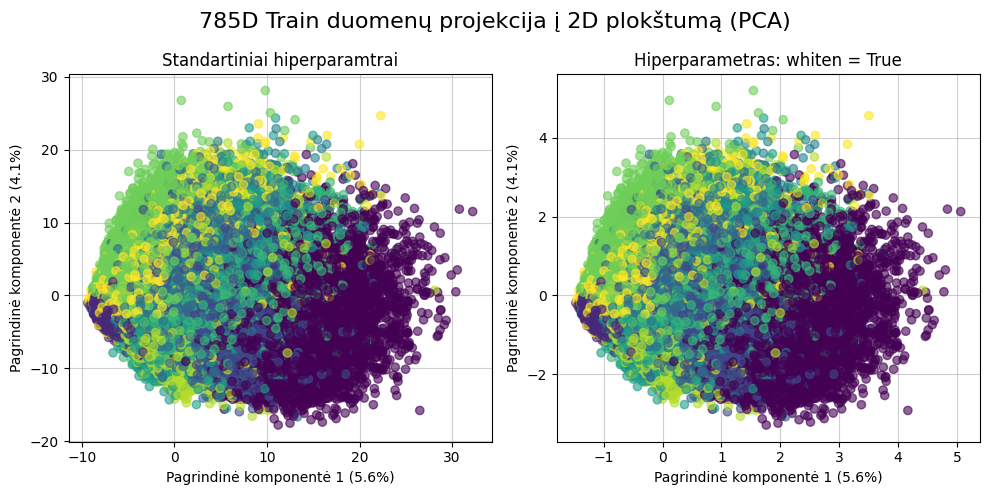

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_train1[:, 0], transformed_train1[:, 1], alpha=0.6, c = y_labels)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_train1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_train1_proc[1]}%)")
ax1.grid(alpha=0.6)
ax1.set_axisbelow(True)

ax2.scatter(transformed_train3[:, 0], transformed_train3[:, 1], alpha=0.6, c = y_labels)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_train3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_train3_proc[1]}%)")
ax2.grid(alpha=0.6)
ax2.set_axisbelow(True)

plt.suptitle("785D Train duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

In [27]:
pca_solvers(train_scaled)

Vykdymo laikai:  {'auto': 0.9276943206787109, 'full': 6.144832372665405, 'covariance_eigh': 0.9915461540222168, 'arpack': 38.38277053833008, 'randomized': 22.456261157989502}


-----

#### Ketvirtas duomenų rinkinys:

In [28]:
df_swissroll = pd.read_csv("swiss_roll_example.csv", sep = ';', header = None)
df_swissroll.head(5)

,0,1,2
0,12.2009,8.8806,-2.1622
1,10.2780,1.9788,8.3610
2,5.5008,12.5690,-2.1587
3,9.7068,9.8894,9.1226
4,-3.3909,14.6149,-10.1192


In [29]:
print("Duomenų struktūra: ", df_swissroll.shape)

Duomenų struktūra:  (400, 3)


In [30]:
swissroll_scaled = sc.fit_transform(df_swissroll)
transformed_swissroll1, variance_swissroll1 = PCA_Algorithm1(swissroll_scaled)
variance_swissroll1_proc = np.round(variance_swissroll1 * 100, decimals = 1)

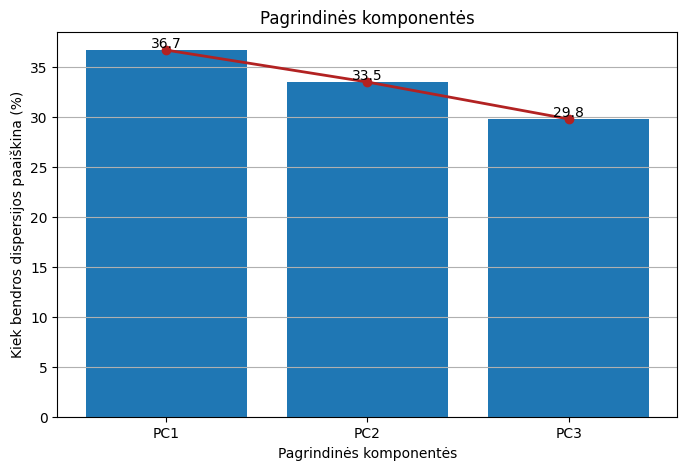

In [31]:
labels = ["PC" + str(x) for x in range(1, len(variance_swissroll1_proc) + 1)]

plt.figure(figsize = (8, 5))
plt.grid(axis = 'y')
bars = plt.bar(x = range(1, len(variance_swissroll1_proc) + 1), height = variance_swissroll1_proc, tick_label = labels)
plt.bar_label(bars)
plt.plot(range(1, len(variance_swissroll1_proc) + 1), variance_swissroll1_proc, marker = 'o', color='firebrick', linewidth = 2, markersize = 6)
plt.title("Pagrindinės komponentės")
plt.ylabel("Kiek bendros dispersijos paaiškina (%)")
plt.xlabel("Pagrindinės komponentės")
plt.show()

In [32]:
transformed_swissroll3, variance_swissroll3 = PCA_Algorithm3(swissroll_scaled)
variance_swissroll3_proc = np.round(variance_swissroll3 * 100, decimals = 1)

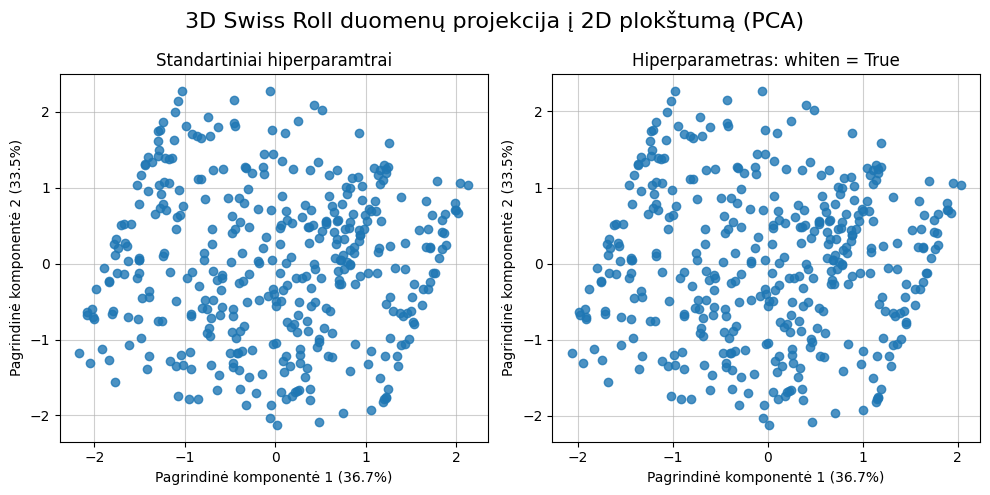

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(transformed_swissroll1[:, 0], transformed_swissroll1[:, 1], alpha=0.8)
ax1.set_title("Standartiniai hiperparamtrai")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({variance_swissroll1_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({variance_swissroll1_proc[1]}%)")
ax1.grid(alpha=0.6)
ax1.set_axisbelow(True)

ax2.scatter(transformed_swissroll3[:, 0], transformed_swissroll3[:, 1], alpha=0.8)
ax2.set_title("Hiperparametras: whiten = True")
ax2.set_xlabel(f"Pagrindinė komponentė 1 ({variance_swissroll3_proc[0]}%)")
ax2.set_ylabel(f"Pagrindinė komponentė 2 ({variance_swissroll3_proc[1]}%)")
ax2.grid(alpha=0.6)
ax2.set_axisbelow(True)

plt.suptitle("3D Swiss Roll duomenų projekcija į 2D plokštumą (PCA)", fontsize=16)
plt.tight_layout()
plt.show()

In [34]:
pca_solvers(swissroll_scaled)

Vykdymo laikai:  {'auto': 0.0020110607147216797, 'full': 0.001999378204345703, 'covariance_eigh': 0.0010027885437011719, 'arpack': 0.0019989013671875, 'randomized': 0.0019979476928710938}


-----

Šaltiniai:
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html